# What to cover in tutorial:
- cover when you should use graphipy
- different modes: full, structure, attributes
- different metrics: show what is already implemented, show how you can use own metric function
- show how perturbing matrix works to deal with singularities -> example of K_2,3
- different types to add ts
- relating to pooling paper -> differences in magnitude for different edge collapses
- show disconnected graphs?

# Outline Tutorial

1. Introduction
    1. when to use graphipy
2. Importing packages 
    import different graphs here?
3. Computing examples
    1. graph structure
        1. $K_{2,3}$ with shortest path metric -> deal with singularities
    2. full (maybe with remark to just features?)
    3. change distance
4. Magnitude Differences

# Graphipy Tutorial

In this tutorial you will learn the main functionalities of the `Graphipy` class, which is used whenever there is a graph structure involved in your data for which you want to compute the magnitude.


TODO roadmap(?)

## Importing Packages

Before we begin, we must import the required packages. Please ensure that you have activated your virtual environment and installed the dependencies using poetry before this step (see **Dependencies** in the README).

In [1]:
# import statements for external packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import networkx as nx

# import statements from magnipy repo
from magnipy.graphipy import Graphipy

## Computing Magnitude

The `Graphipy` package uses `NetworkX` for its graph objects. Hence, let's initialize some `NetworkX` graphs we will use for the first example.

In [2]:
G1 = nx.barbell_graph(8, 4, create_using=None)
G2 = nx.barbell_graph(8, 16, create_using=None)

### Magnitude on the Graph Structure

First, we want to compute magnitude of the graphs' structure only. To do this, we select `mode = 'structure'` while initializing our `Graphipy` objects, this is also the default choice. In that mode the similarity matrix for the magnitude computation is only based on a distance between the nodes in the graph based on its structure. <br>
There are different distances one can use to do this, in the demo we show some different options that are implemented in the `Graphipy` package. Later in the tutorial we will also see how to specify a custom metric function.

In [3]:
magnis1 = []
magnis2 = []

ts = np.linspace(0, 10, 100)

# initialize Graphipy objects for every metric and graph
for metric in [
    "shortest_path_distance",
    "diffusion_distance",
    "resistance_distance",
    "heat_kernel_distance",
]:
    magni1 = Graphipy(G=G1, mode="structure", metric=metric, ts=ts)
    magni1.get_magnitude()
    magnis1.append(magni1)
    magni2 = Graphipy(G=G2, mode="structure", metric=metric, ts=ts)
    magni2.get_magnitude()
    magnis2.append(magni2)

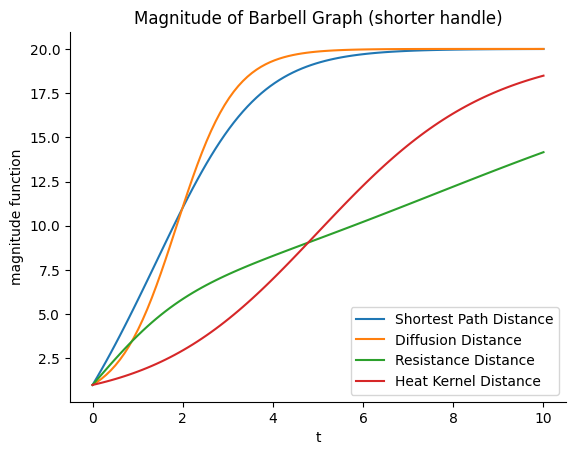

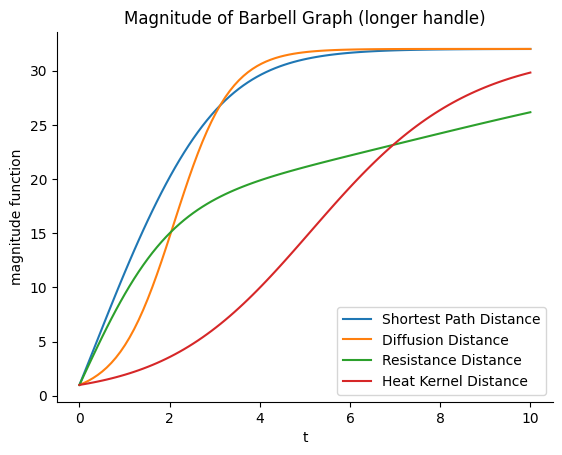

In [4]:
# generate plots

for magni in magnis1:
    magni.plot_magnitude_function()
plt.legend(
    [
        "Shortest Path Distance",
        "Diffusion Distance",
        "Resistance Distance",
        "Heat Kernel Distance",
    ]
)
plt.title("Magnitude of Barbell Graph (shorter handle)")
plt.show()

for magni in magnis2:
    magni.plot_magnitude_function()
plt.legend(
    [
        "Shortest Path Distance",
        "Diffusion Distance",
        "Resistance Distance",
        "Heat Kernel Distance",
    ]
)
plt.title("Magnitude of Barbell Graph (longer handle)")
plt.show()

### Dealing with singularities

Let us consider now the example of the complete bipartite graph $K_{2,3}$ with the shortest path distance. The magnitude function of this graph is known and it contains a singularity. The argument `perturb_singularities` is set to true by default and helps us to deal with cases for which the magnitude is not defined. Let us first set `perturb_singularities` to false and see what happens.

Comment about other way to specify ts.

In [5]:
K23 = nx.complete_multipartite_graph(2, 3)

# initialize graphipy with perturb_singularities=False
magni_sing = Graphipy(
    G=K23,
    mode="structure",
    metric="shortest_path_distance",
    scale_finding="convergence",
    n_ts=13,
    target_prop=0.95,
    perturb_singularities=False,
)

# plotting magnitude function, this will return an error
magni_sing.plot_magnitude_function()

Exception: Exception: 5-th leading minor of the array is not positive definite for t: 0.3193408561480524

Now we set `perturb_singularities` to true. Its effect is that if we encounter a singular matrix then we slightly perturb it and try to compute the magnitude of the perturbed matrix with the hope that the perturbed matrix is not singular anymore. Note that the perturbation can not always resolve the singularity. We chose the example such that the perturbation works, but if we were to compute the magnitude function at more or different scales it will not always be able to resolve the singularity.
There are distances for which we can guarantee that the distance matrix will be positive definite and thus have a well-defined magnitude at every scale. Some examples are $\mathbb{R}^n$ with the Euclidean distance, effective resistance distances, and diffusion distances, which we have seen in the first example.

Exception: 5-th leading minor of the array is not positive definite for t: 0.3193408561480524 perturbing matrix


(-0.5, 5.5)

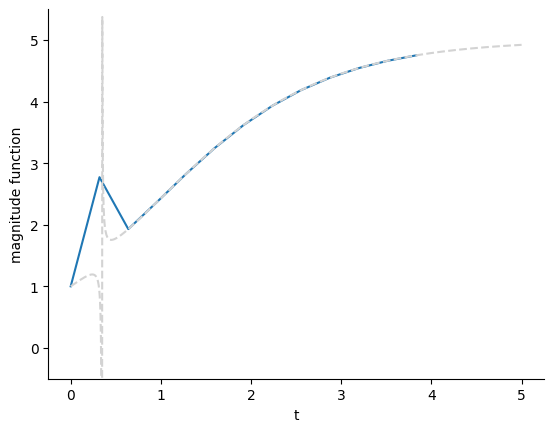

In [6]:
# initialize graphipy with perturb_singularities=True
magni = Graphipy(
    G=K23,
    mode="structure",
    metric="shortest_path_distance",
    scale_finding="convergence",
    n_ts=13,
    target_prop=0.95,
    perturb_singularities=True,
)
magni.get_magnitude()

# plotting magnitude function
magni.plot_magnitude_function()

# this shows the true magnitude function
ts = np.linspace(0, 5, 1000)
plt.plot(
    ts,
    [
        (5 - 7 * np.exp(-t)) / ((1 + np.exp(-t)) * (1 - 2 * np.exp((-2) * t)))
        for t in ts
    ],
    "--",
    color="lightgrey",
)
plt.ylim(-0.5, 5.5)

### Magnitude using Features

If we have an attributed graph where for each node there is a corresponding feature vector, we can take these into account for computing the magnitude. <br>
The mode `full` allows us to compute the magnitude based on the graph structure and the features. To be precise, we compute distances between the features based on a metric we specify when initializing the `Graphipy` object and use these as weights to our graph. The similarity matrix for the magnitude computation is then based on the distances obtained by computing the geodesic distances between the nodes of the weighted graph. 
To pass the features to the `Graphipy` object you can either add node features to the networkX graph, or you can pass a feature matrix $X$.

In [9]:
# initializing everything, move to tutorial_data.py at the end
# this was to see what changes if blobs further apart

np.random.seed(3141)

barbell = 100
bar = 10
G_barb = nx.barbell_graph(barbell, bar)

blob_distance = 1000000000

gauss_blob = np.random.multivariate_normal(
    mean=(0, 0, 0), cov=np.identity(3), size=G_barb.number_of_nodes() + 1
)
other_gauss_blob = np.random.multivariate_normal(
    mean=(blob_distance, 0, 0),
    cov=np.identity(3),
    size=G_barb.number_of_nodes() + 1,
)

X_bar2 = np.array(
    [[10 * t + blob_distance // 2, 0, 0] for t in range(-bar // 2, bar // 2)]
)

X_2blob1000 = np.concatenate(
    (gauss_blob[:barbell], X_bar2, other_gauss_blob[:barbell]), axis=0
)

graphi_full_bb2blob1000 = Graphipy(
    X=X_2blob1000, G=G_barb, mode="full", metric="euclidean"
)
graphi_full_bb2blob1000.get_magnitude()

(array([  1.        ,  14.94990458,  21.39426595,  29.16200647,
         38.66365281,  49.53579509,  61.33251029,  73.6126944 ,
         85.97588043,  98.0827691 , 109.66613842, 120.53353313,
        130.56295953, 139.69354598, 147.91350786, 155.24753851,
        161.74516145, 167.4709137 , 172.49667276, 176.89605928,
        180.740636  , 184.09754184, 187.02820078, 189.58778982,
        191.82521219, 193.7833837 , 195.49969472, 197.00655347,
        198.33194953, 199.5       ]),
 array([0.        , 0.31258119, 0.62516238, 0.93774357, 1.25032476,
        1.56290595, 1.87548714, 2.18806833, 2.50064952, 2.81323071,
        3.1258119 , 3.43839309, 3.75097428, 4.06355547, 4.37613666,
        4.68871785, 5.00129904, 5.31388023, 5.62646142, 5.93904261,
        6.2516238 , 6.56420499, 6.87678618, 7.18936737, 7.50194856,
        7.81452975, 8.12711094, 8.43969213, 8.75227332, 9.06485451]))

In [25]:
# initializing everything, move to tutorial_data.py at the end

np.random.seed(3141)

barbell = 100
bar = 10
G_barb = nx.barbell_graph(barbell, bar)

blob_distance = 100

gauss_blob = np.random.multivariate_normal(
    mean=(0, 0, 0), cov=np.identity(3), size=G_barb.number_of_nodes() + 1
)
other_gauss_blob = np.random.multivariate_normal(
    mean=(blob_distance, 0, 0),
    cov=np.identity(3),
    size=G_barb.number_of_nodes() + 1,
)

X_bar1 = np.array([[0, 10 * t + 20, 0] for t in range(-bar // 2, bar // 2)])
X_bar2 = np.array(
    [[10 * t + blob_distance // 2, 0, 0] for t in range(-bar // 2, bar // 2)]
)

X_1blob = np.concatenate(
    (gauss_blob[:barbell], X_bar1, gauss_blob[barbell + 1 : 2 * barbell + 1]),
    axis=0,
)
X_2blob = np.concatenate(
    (gauss_blob[:barbell], X_bar2, other_gauss_blob[:barbell]), axis=0
)
X_complete = gauss_blob[: G_barb.number_of_nodes()]

In [11]:
# test initalizing via graph attributes

G_barb_1blob = G_barb.copy()
features_barb1blob = {i: X_1blob[i] for i in range(X_1blob.shape[0])}
nx.set_node_attributes(
    G=G_barb_1blob, values=features_barb1blob, name="feature"
)
G_barb_2blob = G_barb.copy()
features_barb2blob = {i: X_2blob[i] for i in range(X_2blob.shape[0])}
nx.set_node_attributes(
    G=G_barb_2blob, values=features_barb2blob, name="feature"
)
G_complete_1blob = nx.complete_graph(G_barb.number_of_nodes())
features_complete1blob = {i: X_complete[i] for i in range(X_complete.shape[0])}
nx.set_node_attributes(
    G=G_complete_1blob, values=features_complete1blob, name="feature"
)
graphi_full_bb1blob_nodeattr = Graphipy(
    G=G_barb_1blob, mode="full", metric="euclidean"
)
graphi_full_bb2blob_nodeattr = Graphipy(
    G=G_barb_2blob, mode="full", metric="euclidean"
)
graphi_full_complete_nodeattr = Graphipy(
    G=G_complete_1blob, mode="full", metric="euclidean"
)

We initialize three Graphipy objects. The first two have the structure of a barbell graph and the last one has a complete graph structure. The features are points in $\mathbb{R}^3$ and can be visualized by executing the cell below. 

In [12]:
graphi_full_bb1blob = Graphipy(
    X=X_1blob, G=G_barb, mode="full", metric="euclidean"
)

graphi_full_bb2blob = Graphipy(
    X=X_2blob, G=G_barb, mode="full", metric="euclidean"
)

graphi_full_c1blob = Graphipy(
    X=X_complete,
    G=nx.complete_graph(G_barb.number_of_nodes()),
    mode="full",
    metric="euclidean",
)

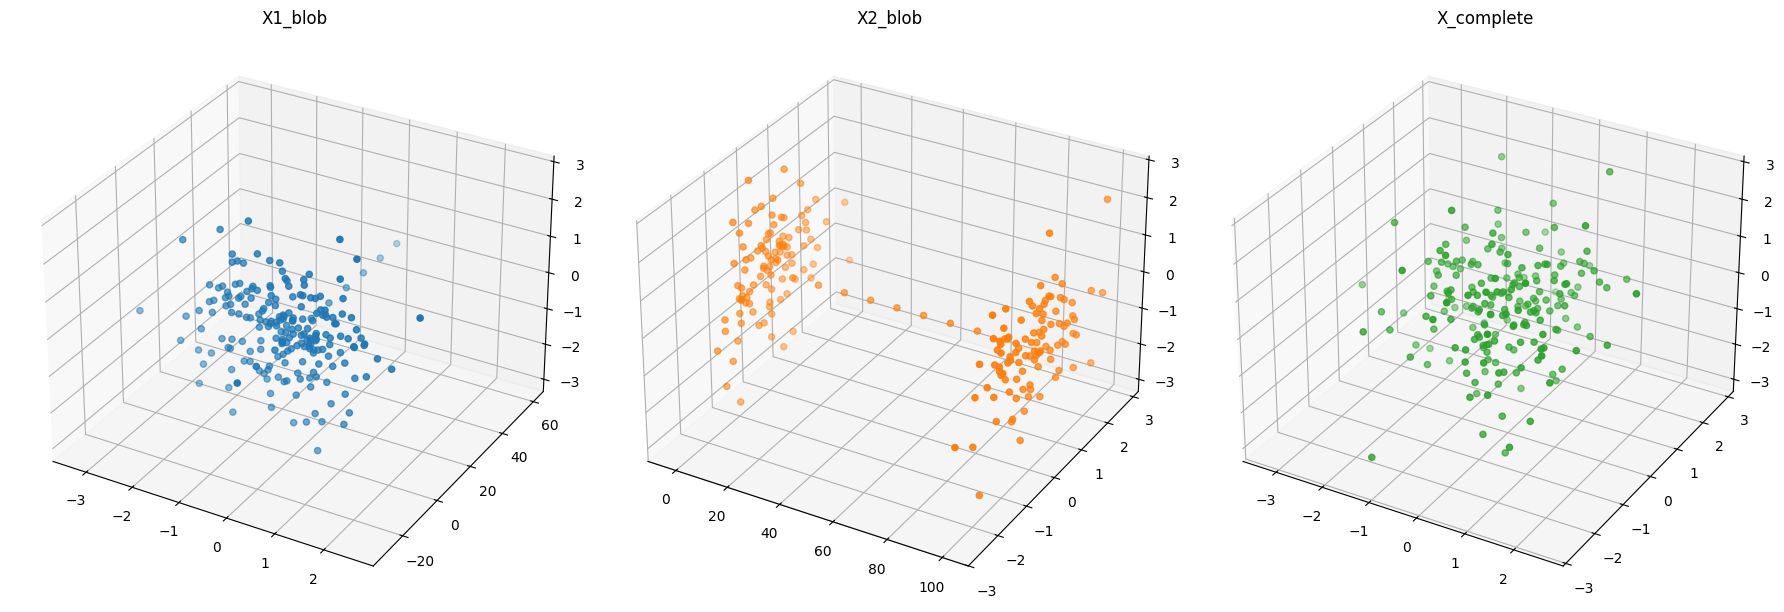

In [13]:
# Executing this cell lets you visualize the features of the three different magnipy objects in this section.
import magnipy.utils.tutorial_data

gauss1_blob_df = pd.DataFrame(X_1blob, columns=["x", "y", "z"])
gauss2_blob_df = pd.DataFrame(X_2blob, columns=["x", "y", "z"])
gauss_blob_df = pd.DataFrame(X_complete, columns=["x", "y", "z"])


magnipy.utils.tutorial_data.plot_dfs(
    [gauss1_blob_df, gauss2_blob_df, gauss_blob_df],
    titles=["X1_blob", "X2_blob", "X_complete"],
)

We compute and plot the magnitude functions for all three examples.

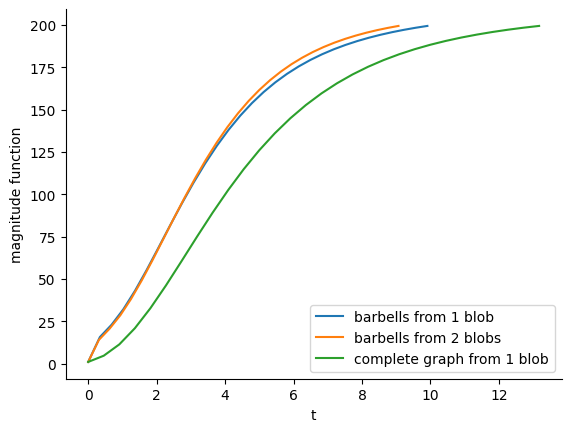

In [14]:
graphi_full_bb1blob.plot_magnitude_function()

graphi_full_bb2blob.plot_magnitude_function()

graphi_full_c1blob.plot_magnitude_function()

plt.legend(
    [
        "barbells from 1 blob",
        "barbells from 2 blobs",
        "complete graph from 1 blob",
    ]
)

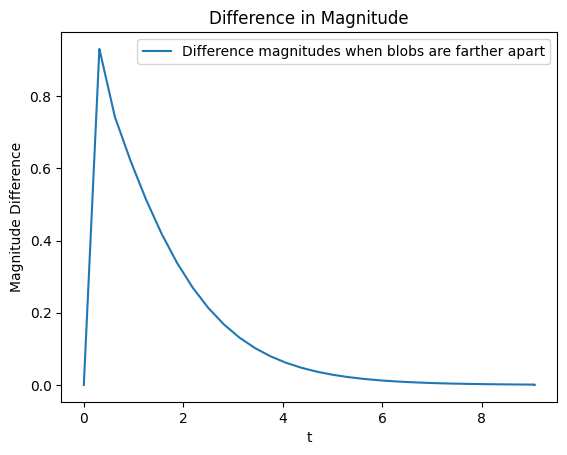

In [15]:
# for me to test, prob remove?

diff_mag_furtherblobs, ts = graphi_full_bb2blob1000._subtract(
    graphi_full_bb2blob
)
import seaborn as sns

sns.lineplot(
    x=ts,
    y=diff_mag_furtherblobs,
    label="Difference magnitudes when blobs are farther apart",
)
plt.title("Difference in Magnitude")
plt.xlabel("t")
plt.ylabel("Magnitude Difference")
plt.legend()

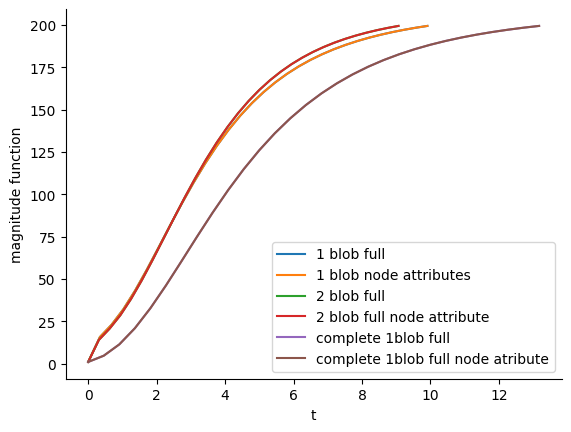

In [16]:
# testing for me, prob remove

graphi_full_bb1blob.plot_magnitude_function()
graphi_full_bb1blob_nodeattr.plot_magnitude_function()
graphi_full_bb2blob.plot_magnitude_function()
graphi_full_bb2blob_nodeattr.plot_magnitude_function()
graphi_full_c1blob.plot_magnitude_function()
graphi_full_complete_nodeattr.plot_magnitude_function()
plt.legend(
    [
        "1 blob full",
        "1 blob node attributes",
        "2 blob full",
        "2 blob full node attribute",
        "complete 1blob full",
        "complete 1blob full node atribute",
    ]
)

Another option is to use the mode `attributes` where we only use a distance between features for the magnitude. This will give the same result as creating a `Magnipy` object using the features as the data with the same choice of distance function. <br>


In [19]:
# initializing objects
graphi_attributes_bb1blob = Graphipy(
    X=X_1blob, G=G_barb, mode="attributes", metric="euclidean", log_scale=True
)

graphi_attributes_bb2blob = Graphipy(
    X=X_2blob, G=G_barb, mode="attributes", metric="euclidean", log_scale=True
)

graphi_attributes_c1blob = Graphipy(
    X=gauss_blob[: 2 * barbell + bar],
    G=nx.complete_graph(2 * barbell + bar),
    mode="attributes",
    metric="euclidean",
    log_scale=True,
)

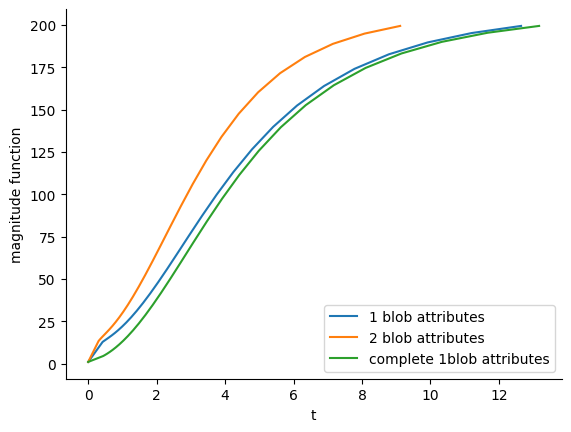

In [20]:
# plotting magnitude functions
graphi_attributes_bb1blob.plot_magnitude_function()
graphi_attributes_bb2blob.plot_magnitude_function()
graphi_attributes_c1blob.plot_magnitude_function()
plt.legend(
    ["1 blob attributes", "2 blob attributes", "complete 1blob attributes"]
)

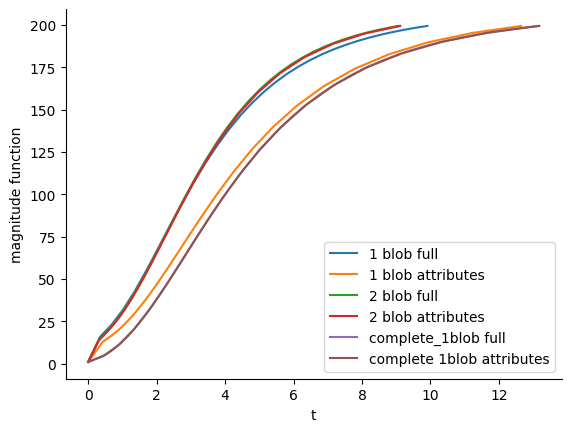

In [21]:
# probably remove, differences between modes full and only attributes
graphi_full_bb1blob.plot_magnitude_function()
graphi_attributes_bb1blob.plot_magnitude_function()
graphi_full_bb2blob.plot_magnitude_function()
graphi_attributes_bb2blob.plot_magnitude_function()
graphi_full_c1blob.plot_magnitude_function()
graphi_attributes_c1blob.plot_magnitude_function()
plt.legend(
    [
        "1 blob full",
        "1 blob attributes",
        "2 blob full",
        "2 blob attributes",
        "complete_1blob full",
        "complete 1blob attributes",
    ]
)

### Using a Custom Distance Function 

Instead of using the implemented distance functions, it is also possible to compute the magnitude using a custom distance function. Make sure that the custom distance function is compatible with the mode you are planning to use. In the example we define a distance based on the graph structure and features, so we use the attributed graph from above.

In [ ]:
from magnipy.magnitude.distances import distances_scipy


# compute_distances(X=None, X2=None, G=None)
def cust_dist(X=None, X2=None, G=None):
    Xown = X_1blob
    X2own = X
    feature_distances = distances_scipy(Xown, X2own, metric="euclidean")
    for e in G.edges():
        G[e[0], e[1]]["weight"] = feature_distances[e[0], e[1]]
    distances = nx.resistance_distance(G=G, weight="weight")
    distances = nx.utils.dict_to_numpy_array(distances)

    return distances

ValueError: XB must be a 2-dimensional array.

In [30]:
# other example biharmonic distance from https://github.com/ll220/biharmonic-kharmonic-clustering?

ts = np.linspace(0, 10, 100)

graphi_custom = Graphipy(
    X=X_1blob, G=G_barb, mode="full", ts=ts, custom_dist_fn=cust_dist
)

ValueError: XB must be a 2-dimensional array.

In [56]:
# compute_distances(X=None, X2=None, G=None)


# TO DO: add check that custom distance has right dimensions
def cust_dist(X=None, X2=None, G=None):

    distances = nx.resistance_distance(G=G)
    distances = nx.utils.dict_to_numpy_array(distances)

    return distances[:5, :5]


cust_dist(G=G1).shape

(5, 5)

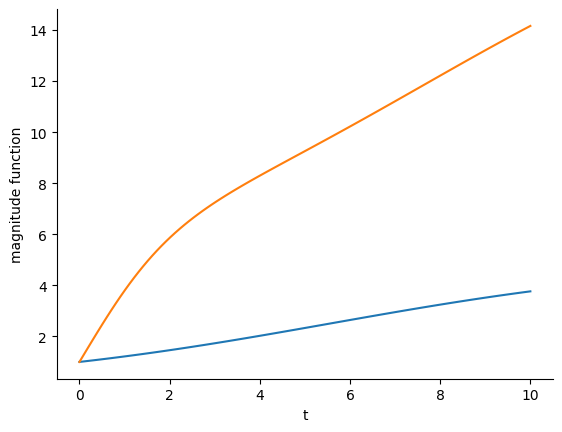

In [57]:
graphi_custom.plot_magnitude_function()
magnis1[2].plot_magnitude_function()

## Computing Differences in Magnitude

Computing the difference in magnitude can be insightful for comparing the difference in diversity between two spaces. The `Graphipy` package includes a `_substract` method which can be used for this task. <lb>
One appplication can be found in 'Geometry-aware Edge Pooling for Graph Neural Networks' where the difference in diversity is used to decide which edge to collapse in order to find a structure preserving pooling method. The examples below demonstrate this.

In [31]:
# We create a graph G consisitng of two cliques connected by a path. Then we obtain two variations of the graph by contracting either an edge in a clique or an edge in the path.

n = 7
m = 3
bar = 2

Kn = nx.complete_graph(n)
Km = nx.complete_graph(m)
pathG = nx.path_graph(bar)

nx.relabel_nodes(
    Kn, {n: n if n == 0 else f"n-{n}" for n in Kn.nodes}, copy=False
)
nx.relabel_nodes(
    Km, {n: n if n == bar - 1 else f"m-{n}" for n in Km.nodes}, copy=False
)

G = nx.compose_all([Kn, Km, pathG])
G_contr_path = nx.contracted_edge(G, (0, 1), self_loops=False)
G_contr_clique = nx.contracted_edge(
    G, (f"n-{n-1}", f"n-{n-2}"), self_loops=False
)

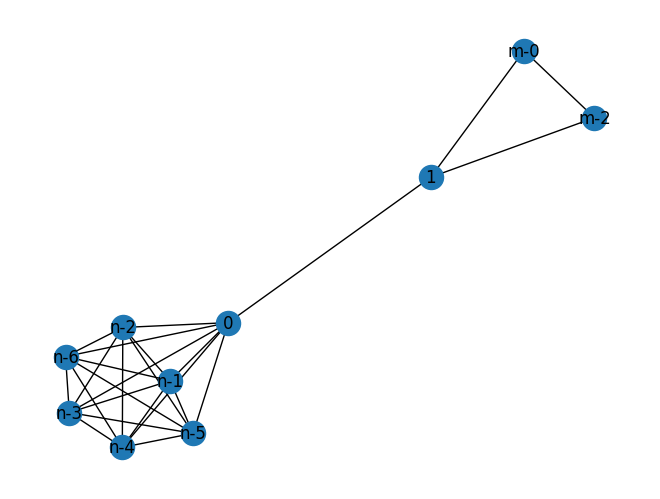

In [32]:
# add nicer visualization

nx.draw_spring(G, with_labels=True)

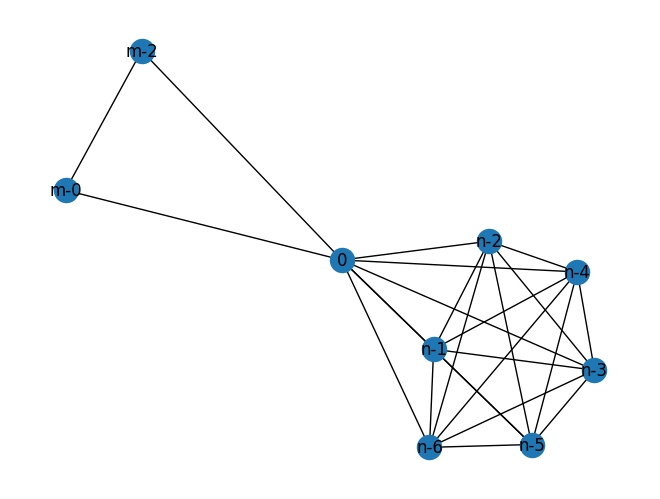

In [33]:
nx.draw_spring(G_contr_path, with_labels=True)

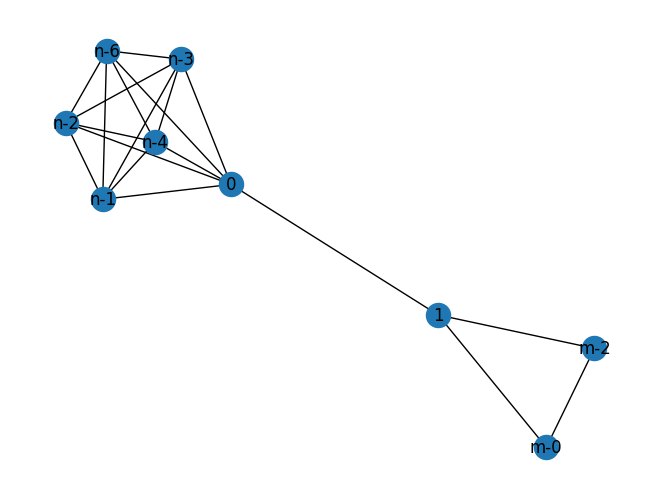

In [34]:
nx.draw_spring(G_contr_clique, with_labels=True)

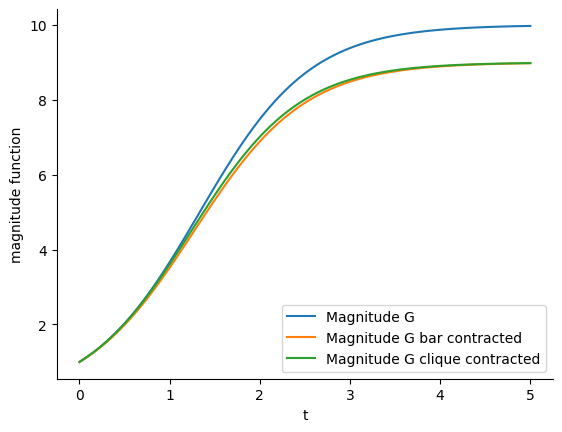

In [35]:
# initializing the grahipy objects
ts = np.linspace(0, 5, 100)

graphi = Graphipy(G=G, ts=ts, metric="diffusion_distance", mode="structure")
graphi_bar_contracted = Graphipy(
    G=G_contr_path, ts=ts, metric="diffusion_distance", mode="structure"
)
graphi_clique_contracted = Graphipy(
    G=G_contr_clique, ts=ts, metric="diffusion_distance", mode="structure"
)

# #plotting magnitude functions
graphi.plot_magnitude_function()
graphi_bar_contracted.plot_magnitude_function()
graphi_clique_contracted.plot_magnitude_function()
plt.legend(
    [
        "Magnitude G",
        "Magnitude G bar contracted",
        "Magnitude G clique contracted",
    ]
)

# computing the differences in magnitude
diff_bar_contracted, diff_ts_bar = graphi._subtract(other=graphi_bar_contracted)
diff_clique_contracted, diff_ts_clique = graphi._subtract(
    other=graphi_clique_contracted
)

Plotting the differences between the graphs with an edge contracted and the original graph we see that contracting the edge in the clique results in a smaller loss in diversity than contracting the edge connecting the two cliques.

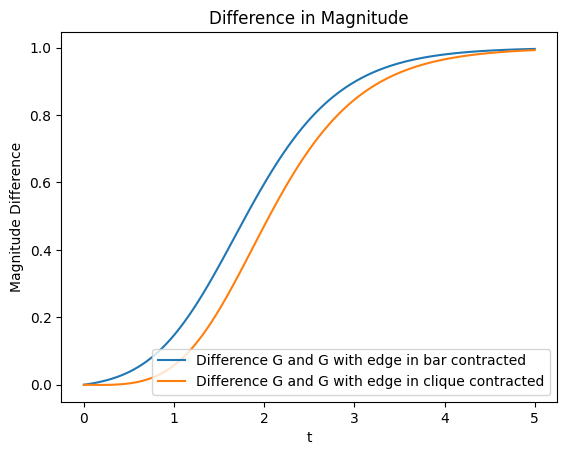

In [36]:
# vizualizing the differences in magnitude
sns.lineplot(
    x=ts,
    y=diff_bar_contracted,
    label="Difference G and G with edge in bar contracted",
)
sns.lineplot(
    x=ts,
    y=diff_clique_contracted,
    label="Difference G and G with edge in clique contracted",
)

plt.title("Difference in Magnitude")
plt.xlabel("t")
plt.ylabel("Magnitude Difference")
plt.legend()

We can also compute the differences in magnitude for the attributed graphs from the previous section.

In [37]:
mag_diff_bb1c, ts_bb1c = graphi_full_bb1blob._subtract(other=graphi_full_c1blob)
mag_diff_bb2c, ts_bb2c = graphi_full_bb2blob._subtract(other=graphi_full_c1blob)
mag_diff_bb2c_far, ts_bb2c_far = graphi_full_bb2blob1000._subtract(
    other=graphi_full_c1blob
)

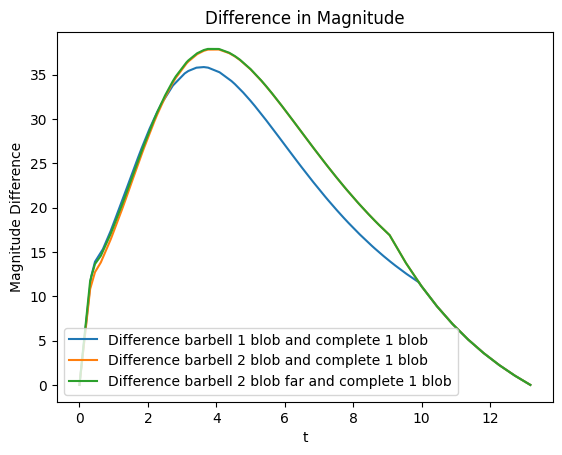

In [38]:
ts = graphi_full_bb1blob._ts
sns.lineplot(
    x=ts_bb1c,
    y=mag_diff_bb1c,
    label="Difference barbell 1 blob and complete 1 blob",
)
sns.lineplot(
    x=ts_bb2c,
    y=mag_diff_bb2c,
    label="Difference barbell 2 blob and complete 1 blob",
)
sns.lineplot(
    x=ts_bb2c_far,
    y=mag_diff_bb2c_far,
    label="Difference barbell 2 blob far and complete 1 blob",
)

plt.title("Difference in Magnitude")
plt.xlabel("t")
plt.ylabel("Magnitude Difference")
plt.legend()